In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
import matplotlib.gridspec as gridspec
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')


In [74]:
df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/5. Clustering/EastWestAirlines.csv')
df.head(5)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
df.drop('ID#', axis =1,inplace = True)

In [4]:
print("="*88)
print("STEP 1: DATASET OVERVIEW")
print("="*88)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Missing : {df.isnull().sum().sum()}")
print("\nStatistics:")
print(df.describe().T.round(0).to_string())

STEP 1: DATASET OVERVIEW
Rows    : 3999
Columns : 11
Missing : 0

Statistics:
                    count     mean       std  min      25%      50%      75%        max
Balance            3999.0  73601.0  100776.0  0.0  18528.0  43097.0  92404.0  1704838.0
Qual_miles         3999.0    144.0     774.0  0.0      0.0      0.0      0.0    11148.0
cc1_miles          3999.0      2.0       1.0  1.0      1.0      1.0      3.0        5.0
cc2_miles          3999.0      1.0       0.0  1.0      1.0      1.0      1.0        3.0
cc3_miles          3999.0      1.0       0.0  1.0      1.0      1.0      1.0        5.0
Bonus_miles        3999.0  17145.0   24151.0  0.0   1250.0   7171.0  23800.0   263685.0
Bonus_trans        3999.0     12.0      10.0  0.0      3.0     12.0     17.0       86.0
Flight_miles_12mo  3999.0    460.0    1400.0  0.0      0.0      0.0    311.0    30817.0
Flight_trans_12    3999.0      1.0       4.0  0.0      0.0      0.0      1.0       53.0
Days_since_enroll  3999.0   4119.0    2065

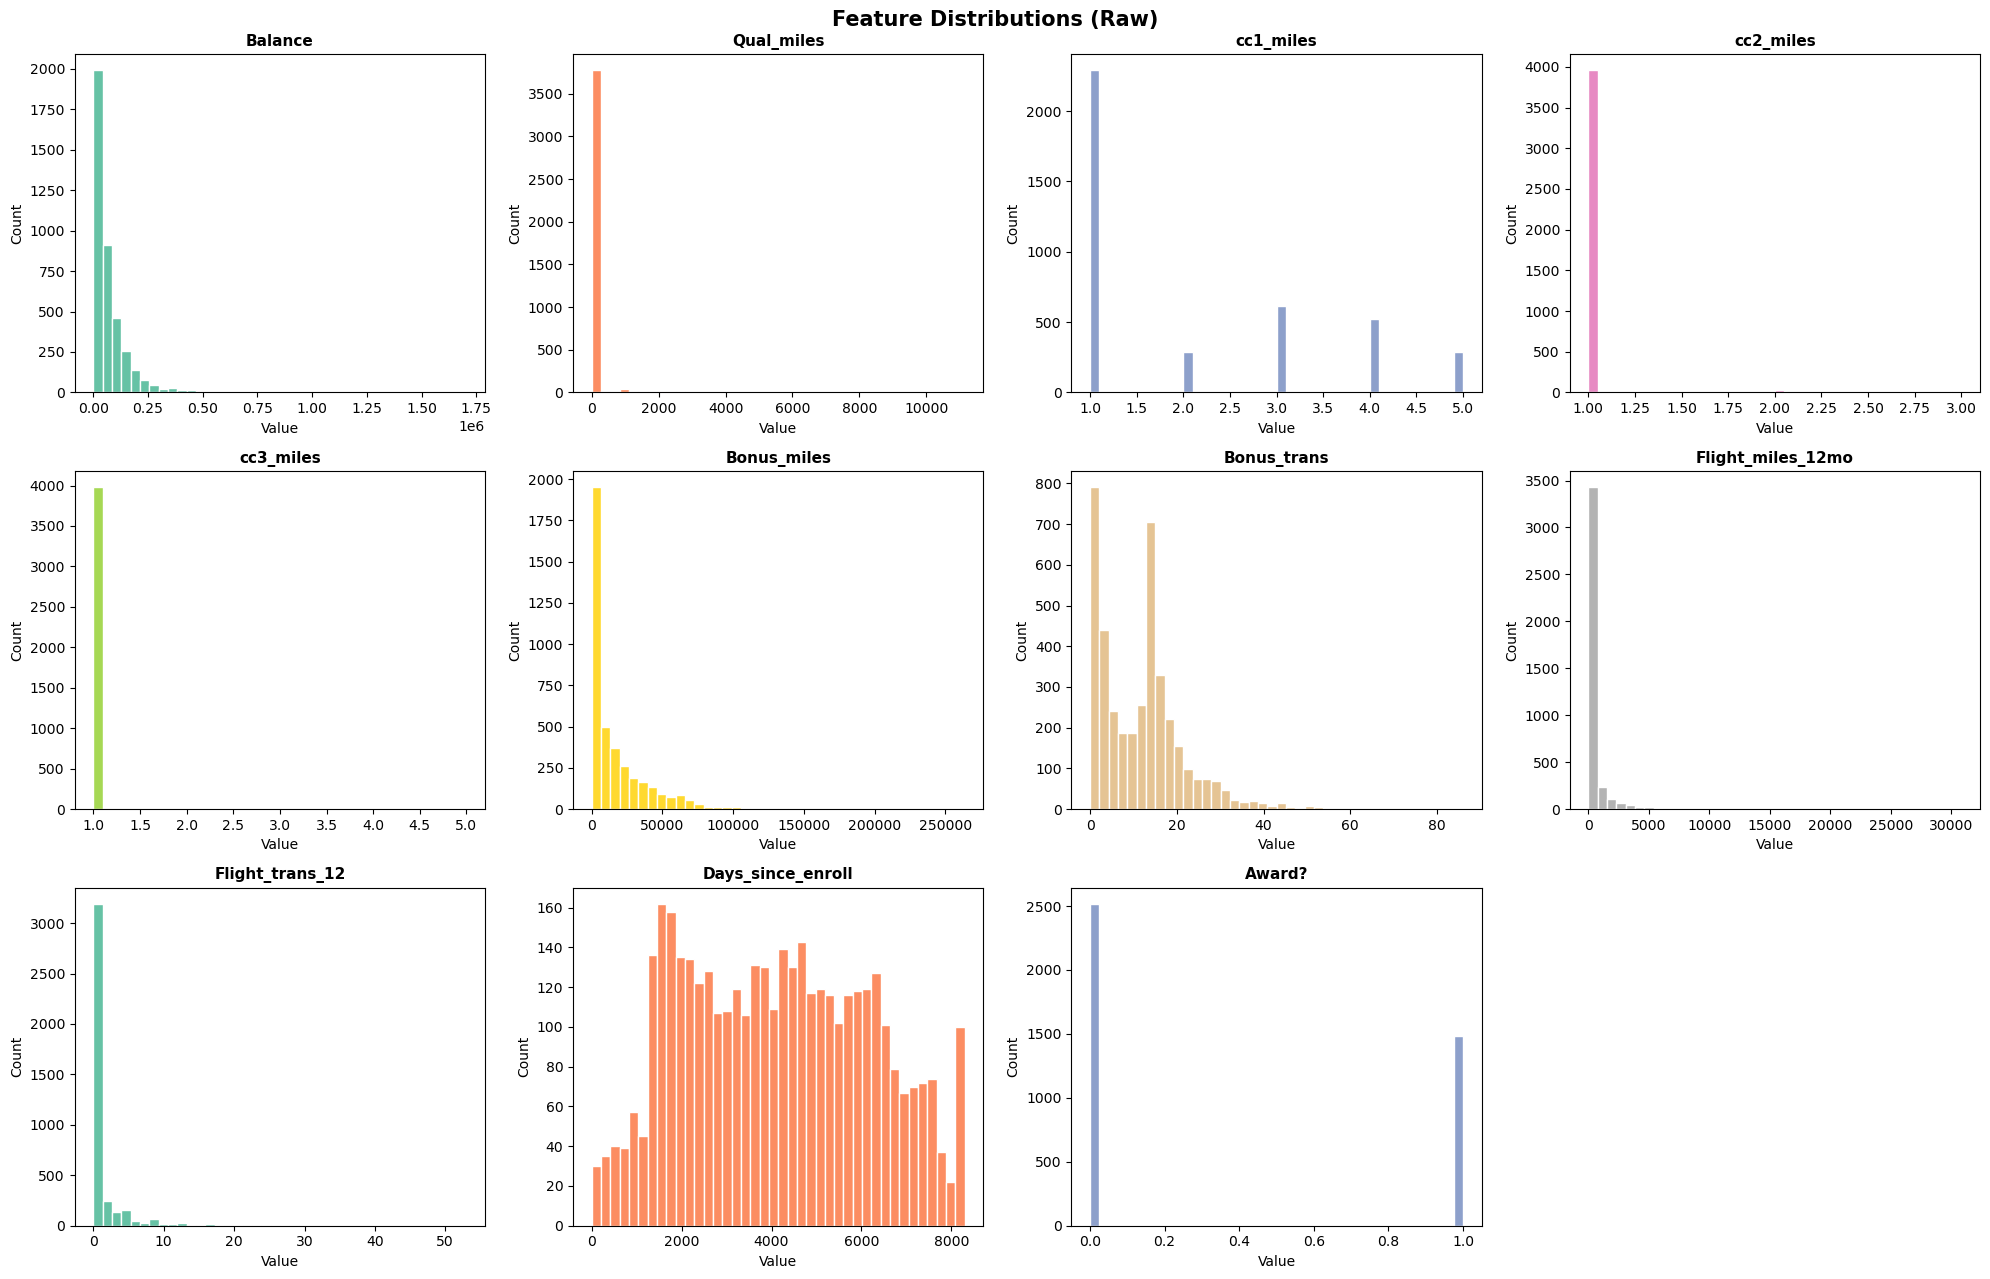

In [5]:
P = sns.color_palette("Set2", len(df.columns))
%matplotlib inline
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle("Feature Distributions (Raw)", fontsize=15, fontweight="bold")
axes = axes.flatten()
 
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, color=P[i % len(P)], edgecolor="white")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

axes[11].set_visible(False)
plt.tight_layout()
plt.show()

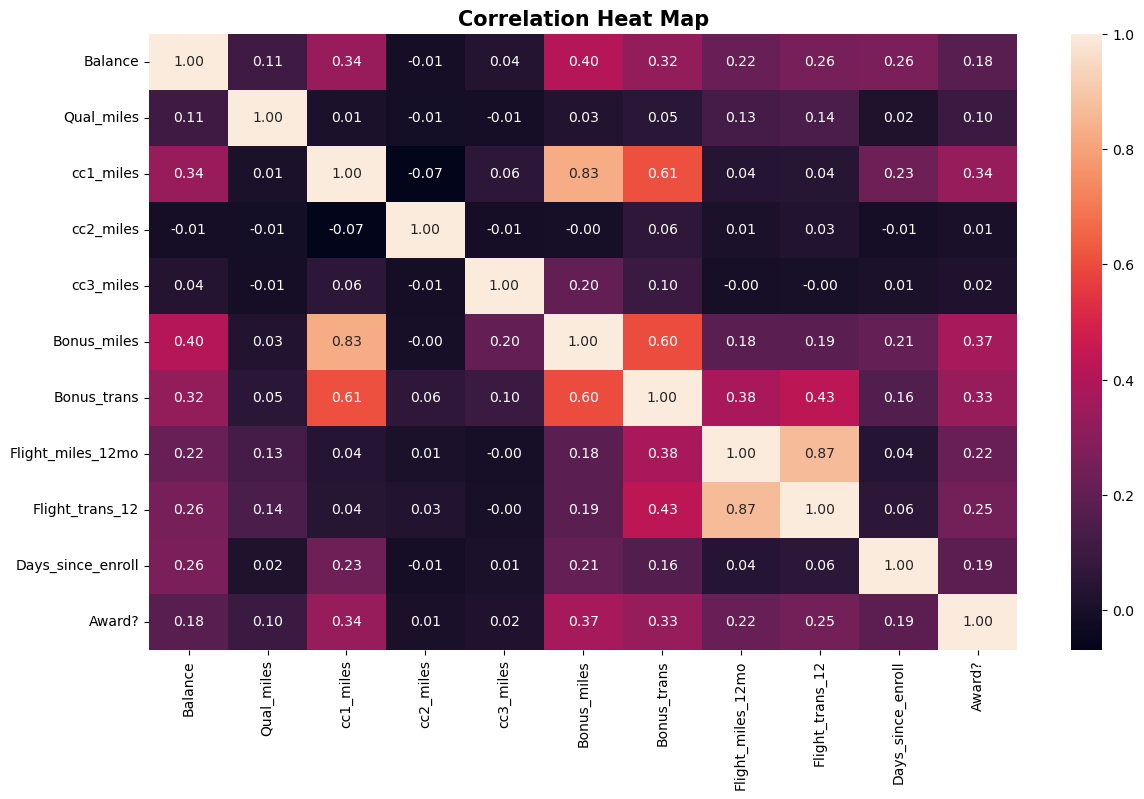

In [6]:
plt.figure(figsize =(14,8))
corr = df.corr()

sns.heatmap(corr, annot = True, fmt ='.2f')
plt.title("Correlation Heat Map", fontsize = 15, fontweight ='bold')
plt.show()

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

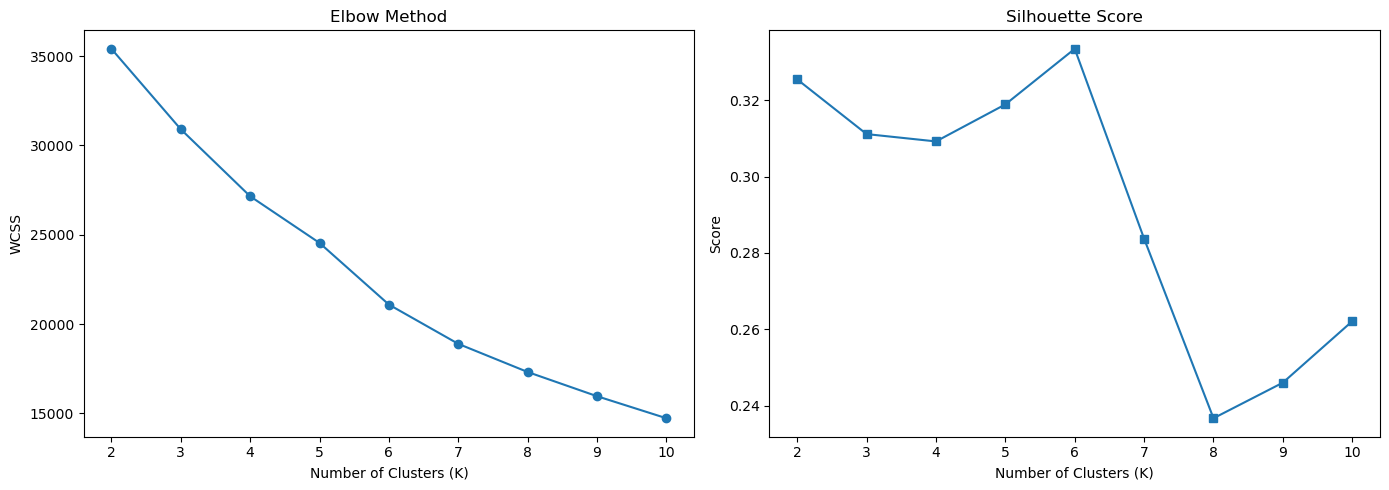

 Reading the charts:
• Elbow: The sharpest bend is at k=4 (diminishing returns after
• Silhouette: Relatively stable from k=2–6; k=4 is a good balance


In [17]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS")

axes[1].plot(k_range, silhouette_scores, marker='s')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

print(" Reading the charts:")
print("• Elbow: The sharpest bend is at k=4 (diminishing returns after")
print("• Silhouette: Relatively stable from k=2–6; k=4 is a good balance")

In [ ]:
k_values = list(k_range)
best_index = np.argmax(silhouette_scores)
best_k = k_values[best_index]

In [71]:
km_final = KMeans(n_clusters=6, init="k-means++", n_init=15,
                  max_iter=500, random_state=42)
df["KM_Cluster"] = km_final.fit_predict(X_scaled)

print(df["KM_Cluster"].value_counts().sort_index())
print(f"Silhouette: {silhouette_score(X_scaled, df['KM_Cluster']):.4f}")

KM_Cluster
0    1253
1    2484
2     143
3      43
4      15
5      61
Name: count, dtype: int64
Silhouette: 0.3334


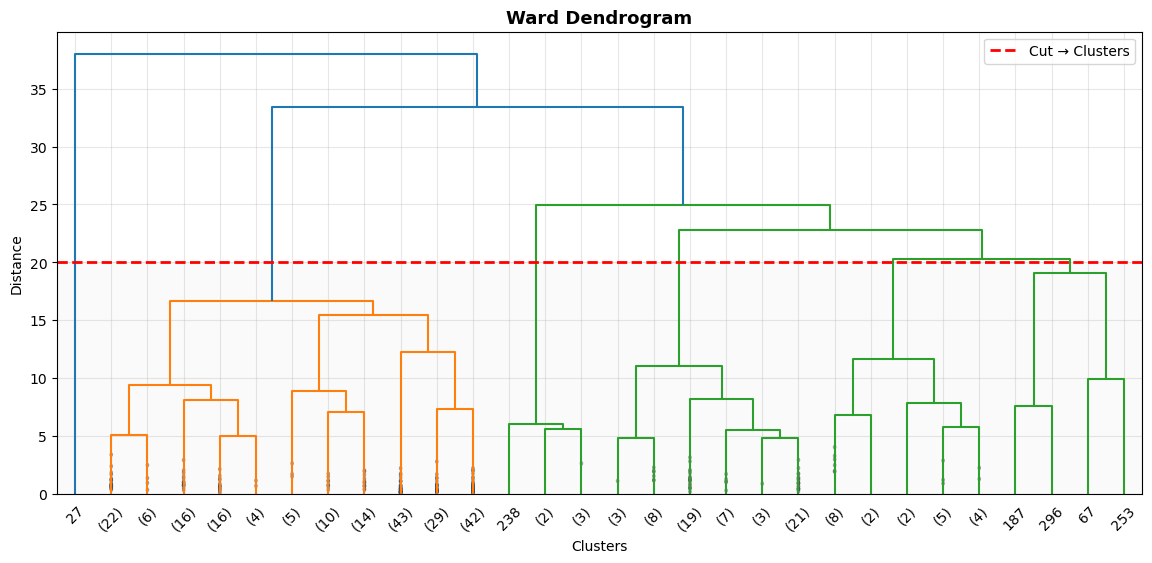

In [28]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode='lastp',   
    p=30,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)
cut_height = 20
plt.axhspan(0, cut_height, color='#f0f0f0', alpha=0.3)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2, label='Cut → Clusters')

plt.title("Ward Dendrogram", fontsize=13, fontweight='bold')
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.legend()
plt.grid(alpha=.3)

plt.show()

In [69]:
hc = AgglomerativeClustering(n_clusters=6, linkage='ward')
df["HC_Cluster"] = hc.fit_predict(X_scaled)

In [70]:
print(f"{'Metric':<25} {'K-Means':>10} {'Hierarchical':>14}")
print(f"Silhouette:                  {silhouette_score(X_scaled, df['KM_Cluster']):.4f}  vs  {silhouette_score(X_scaled, df['HC_Cluster']):.4f}")

Metric                       K-Means   Hierarchical
Silhouette:                  0.3334  vs  0.3193


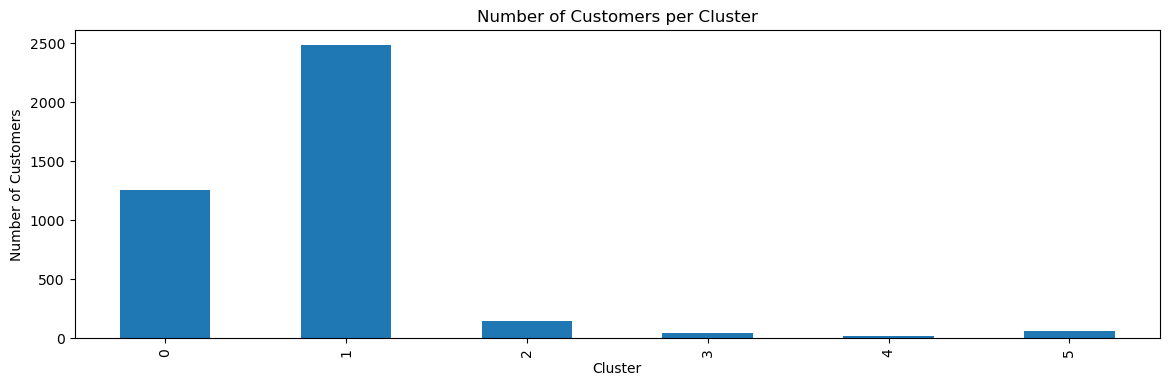

In [51]:
plt.figure(figsize = (14,4))
cluster_counts.plot(kind='bar')
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

In [72]:
cluster_counts = df['KM_Cluster'].value_counts().sort_index()
cluster_counts
cluster_percent = (cluster_counts / len(df)) * 100
cluster_counts, round(cluster_percent,2)

(KM_Cluster
 0    1253
 1    2484
 2     143
 3      43
 4      15
 5      61
 Name: count, dtype: int64,
 KM_Cluster
 0    31.33
 1    62.12
 2     3.58
 3     1.08
 4     0.38
 5     1.53
 Name: count, dtype: float64)

# Cluster 0 – Bonus Collectors (1,253 passengers, 31.33%)
* Highest Bonus_miles (93,928) but low flight miles — earn miles through credit cards & partners, not flying
* High cc3_miles (Small Business card) — likely small business owners
* Strategy: Target with partner offers, hotel/car rental bonuses, and credit card promotions

# Cluster 1 – Moderate Travelers (2484 passengers, 62.12%)
* Balance and Bonus_miles with moderate flight activity
* Occasional travelers with steady but not high engagement
* Strategy: Encourage loyalty through personalized offers and mid-tier reward programs

# Cluster 2 – Low Engagement Customers (143 passengers, 3.58%)
* Lowest flight activity and mileage accumulation
* Minimal interaction with airline services
* Strategy: Use discounts, email campaigns, and onboarding offers to increase engagement

# Cluster 3 – Frequent Flyers (43 passengers, )1.08%)
* High Flight_miles_12mo and Flight_trans_12 — frequent active travelers
* Consistent usage of airline services
* Strategy: Provide premium benefits, upgrades, and loyalty rewards to retain them

# Cluster 4 – High Balance Inactive (15 passengers, 0.38%)
* High Balance but low recent flight activity — previously active customers
* Indicates possible churn risk
* Strategy: Reactivation campaigns, exclusive return offers, and bonus mile incentives

# Cluster 5 – Redeemers (61 passengers,   1.53%)
* Frequent flyers but relatively low balance — likely redeem miles often
* Active but not accumulating long-term value
* Strategy: Improve retention with better redemption value and loyalty perks

# Conclusion

The clustering analysis reveals a highly skewed distribution, where a majority of customers fall into a single mass segment, while smaller clusters represent niche but valuable customer groups.

- Cluster 1 dominates the dataset and represents average users
- Cluster 0 forms a significant segment focused on bonus mile accumulation
- Smaller clusters (3, 4, 5) represent high-value or behavior-specific groups such as frequent flyers and at-risk customers

These insights enable the airline to design targeted marketing strategies, improve customer retention, and optimize loyalty programs for different customer segments.